In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns
from PlanningDynamics import utils, plotting, graph
from PlanningDynamics.dataClass import nwbWrapper

from tqdm import tqdm 
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

loading trial data:
loading trials:


100%|██████████| 563/563 [00:00<00:00, 680.94it/s]


loading choice data:


100%|██████████| 1383/1383 [00:01<00:00, 1332.34it/s]


loading trial data:
loading trials:


...

100%|██████████| 2417/2417 [00:01<00:00, 1854.59it/s]


loading trial data:
loading trials:


100%|██████████| 720/720 [00:00<00:00, 1610.00it/s]


loading choice data:


100%|██████████| 1499/1499 [00:00<00:00, 2743.78it/s]


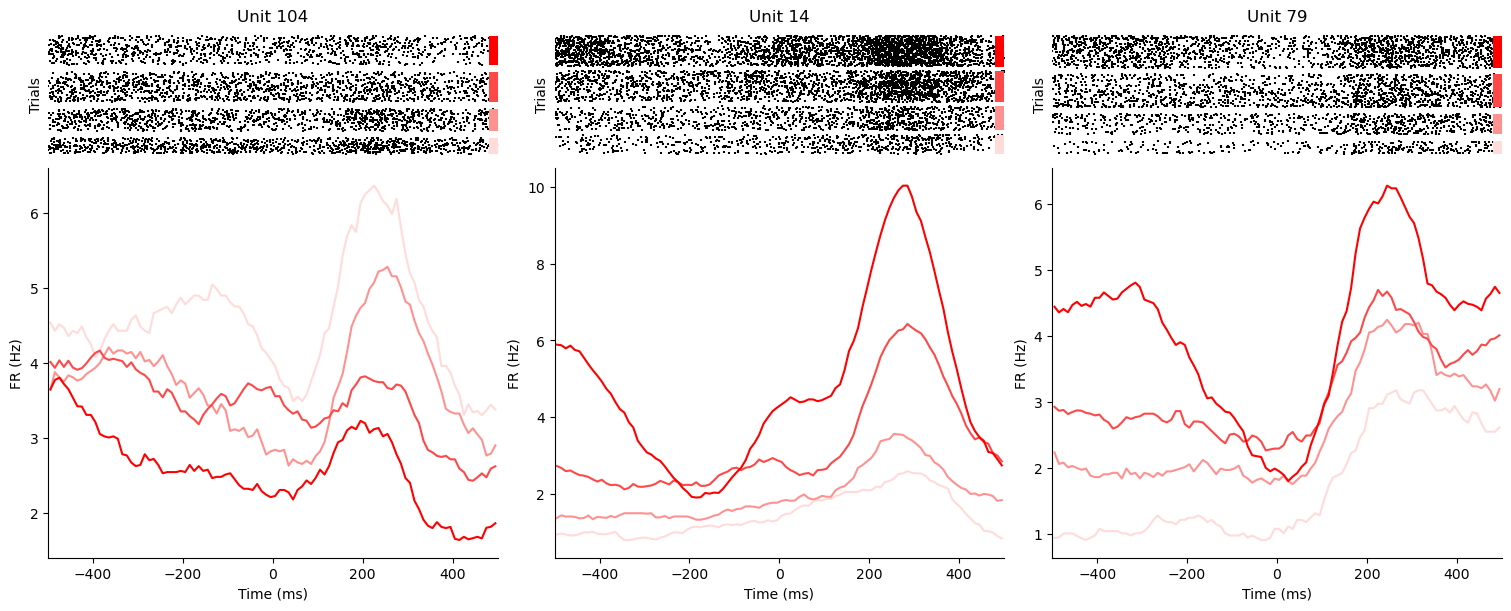

In [ ]:
def fig2A(ax, data, unit):
    choice_colors = plotting.interpolate_colors(color2="#ff0000", color1="#ffdbd9", num_colors=4)
    values = data.choice_df.graph_distance.values#[idx]
    values[values >= 4] = 3
    values = 4 - values
    value_argsort = np.argsort(values)
    
    values = values[value_argsort]
    spikes = data.choice_spikes[value_argsort, :, unit]
 
    w = 75
    smoothed_spikes = utils.movmean(spikes, w, gpu=True)
    Y, X = np.where(spikes)
    
    for v in [1, 2, 3, 4]:
        idx = np.where(values == v)[0]
        if len(idx) == 0:
            continue
        t = np.arange(-500, 500)
        fr = smoothed_spikes[idx, :].mean(axis=0)*1000
        steps = np.arange(0, len(t), 10) + 5
        ax[1].plot(t[steps], fr[steps], label=f"Value {v}", c=choice_colors[v-1])
        y_idx = (Y >= idx[0])& (Y < idx[-1])
        buffer = 100
        ax[0].scatter(X[y_idx] - 500, Y[y_idx] + buffer*v, s=1, marker="|", c="k")
        ax[0].add_patch(Rectangle([480, Y[y_idx][0] + buffer*v], width=20, height=Y[y_idx][-1] - Y[y_idx][0], color=choice_colors[v-1], alpha=1, lw=0))
                
    for i in range(2):
        ax[i].set_xlim([-500, 500])
        
    ax[1].set_xlabel("Time (ms)")
    ax[0].set_ylabel("Trials")
    ax[1].set_ylabel("FR (Hz)")
    
    sns.despine(ax=ax[1])
    sns.despine(ax=ax[0], left=True, bottom=True)
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[0].set_title(f"Unit {unit}")
    
fnames = utils.get_filenames()
neurons = [{"fname": fnames["bart"][0], "n":104}, 
           {"fname": fnames["london"][4], "n":14},
           {"fname": fnames["bart"][2], "n":79}]

fig, ax = plt.subplots(2, 3, figsize=(15, 6), gridspec_kw={"height_ratios": [1, 3]}, constrained_layout=True)
for i, neuron in enumerate(neurons):
    data = nwbWrapper(neuron["fname"], region="OFC")
    fig2A(ax[:, i], data, neuron["n"])
plt.show()

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 591.73it/s]


loading choice data:


100%|██████████| 2545/2545 [00:01<00:00, 1436.16it/s]


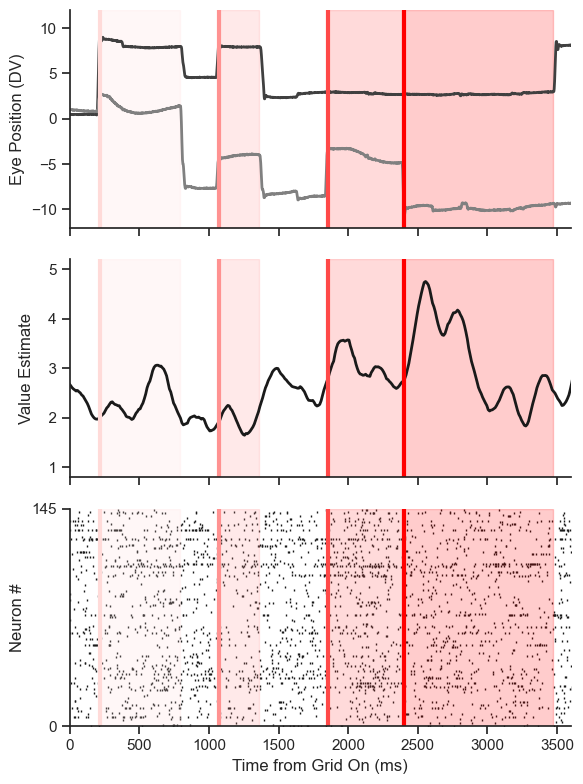

In [5]:
np.random.seed(100)
colors = plotting.interpolate_colors(color2="#ff0000", color1="#ffdbd9", num_colors=4)
def fig2B():
    data = nwbWrapper(fnames["london"][6], region="OFC")

    trial = 716    
    def fit_lasso_loo(data, trial):
        X = data.choice_spikes[:, 500:800, :].mean(axis=1)
        distance = data.choice_df.graph_distance.values
        distance[distance >= 4] = 4
        y = 4 - distance

        train_idx = (data.choice_df.trial != trial)
        from sklearn.pipeline import Pipeline
        model = Pipeline([("zscore", StandardScaler()), ("lasso", LassoCV())])
        model.fit(X[train_idx], y[train_idx])
        return model 

    model = fit_lasso_loo(data, trial)  
    n_cells = data.n_cells
    neuron_order = np.random.permutation(n_cells)

    spikes = data.trial_spikes[trial]
    step_size=10
    trial_ts = utils.trial_ts(spikes) 
    
    sns.set(style="ticks")
    fig, ax = plt.subplots(3, 1, figsize=(6, 8), height_ratios=[1, 1, 1], 
                        sharex=True, tight_layout=True)

    def plot_eyes(ax):
        ax.plot(spikes.eyes[:, 0], lw=2, c=np.ones(3)*0.25)
        ax.plot(spikes.eyes[:, 1], lw=2, c=np.ones(3)*0.5)
        ax.set_ylim([-12, 12])
        ax.set_ylabel("Eye Position (DV)")
    
    def plot_lasso(ax):
        trial_spikes = utils.matrix_square_window(spikes.neural, window_size=[5, 145], step_size=step_size)
        trajectory = utils.movmean(model.predict(trial_spikes), 5).flatten()
        t = np.arange(0, len(trajectory)) * step_size
   
        ax.plot(t, trajectory, lw=2, c="k")
        ax.set_yticks([0, 1, 2, 3, 4, 5], labels=["    0", "  1", "  2", "  3", "4", "5"])
        ax.set_ylim([0.8, 5.2])
        ax.set_ylabel("Value Estimate")
    
    def plot_raster(ax):
        for j in range(n_cells):
            x = np.where(spikes.neural[:, neuron_order[j]])
            y = np.ones_like(x) * j
            ax.scatter(x, y, s=1, c="k", marker = "|", linewidths=1)
        ax.set_ylim(0, n_cells)
        ax.set_xlim([trial_ts["start"], trial_ts["reward"]])
        ax.set_yticks([0, n_cells])

        x_ticks = np.arange(int(trial_ts["start"]), int(trial_ts["start"]) + 4000, 500)
        x_tick_labels = x_ticks - x_ticks[0]
        ax.set_xticks(x_ticks, labels=x_tick_labels)
        ax.set_xlabel("Time from Grid On (ms)")
        ax.set_ylabel("Neuron #")

    def highlight_fixations(ax, trial):
        choices = data.choice_df.query("trial == @trial")
        for i in range(3):
            #ax[i].axvline(ts["start"])
            #ax[i].axvline(ts["first_choice"])
            #ax[i].axvline(ts["reward"], c="g", lw=2)
            #ax[i].set_xlim(t[0], t[-1])
            
            for choice in choices.reset_index().iterrows():
                on = choice[1].fix_on - trial_ts["ml_start_time"]
                off = choice[1].fix_off - trial_ts["ml_start_time"]
                ax[i].axvline(on, c=colors[choice[0]], lw=3)
                
                #ax[i].axvline(off, c=colors[step[0]], linestyle="--", lw=0.5)
                #ax[i].add_patch(Rectangle((on, -1000), off - on, 2000, color=colors[step[0]], alpha=0.2))
                ax[i].axvspan(on, off, color=colors[choice[0]], alpha=0.2)
    
    plot_eyes(ax[0])
    plot_lasso(ax[1])
    plot_raster(ax[2])
    highlight_fixations(ax, trial)
              
    sns.despine()

fig2B()

In [ ]:
def fig2C():
    fnames = utils.get_filenames()
    
    def lasso_loo(fname):     
            data = nwbWrapper(fname, region="OFC")
            X = data.choice_spikes[:, 500:800, :].mean(axis=1)
            y = data.choice_df.graph_distance.values
            y[y >= 4] = 4
            y = 4 - y
            loo = LeaveOneOut().split(X)
            step_size = 5
            predicted_value = np.zeros([X.shape[0], int(1000/step_size)])

            for train, test in tqdm(loo):
                model = Pipeline([("zscore", StandardScaler()), ("lasso", LassoCV())])
                model.fit(X[train], y[train])
                sample_spikes = utils.matrix_square_window(data.choice_spikes[test].squeeze(), window_size=[5, 145], step_size=5)
                predicted_value[test] = model.predict(sample_spikes)
                    
            r = np.zeros(int(1000/step_size))
            mse = np.zeros(int(1000/step_size))
            
            for i in range(predicted_value.shape[1]):
                r[i] = pearsonr(y, predicted_value[:, i]).statistic
                mse[i] = mean_squared_error(y, predicted_value[:, i])
            return r, mse
        
    lasso_results = utils.iterate_subjects(fnames, lasso_loo)
            
    cs = [0.5, 0.8]
    _, ax = plt.subplots(1, 1, figsize=(4, 4), tight_layout=True)
    for j, key in enumerate(lasso_results.keys()):
        
        n_sessions = len(lasso_results[key])
        r = np.array([lasso_results[key][i][0] for i in range(n_sessions)])
        t = np.arange(-500, 500, 5)
        
        ax.plot(t, r.mean(axis=0), c=np.ones(3)*cs[j], label=key[0].capitalize())
        ax.fill_between(t, r.mean(axis=0) - r.std(axis=0)/np.sqrt(n_sessions),
                            r.mean(axis=0) + r.std(axis=0)/np.sqrt(n_sessions), color=np.ones(3)*cs[j], alpha=0.3)
        ax.set_xlim([-400, 400])
    ax.set_xlabel("Time from choice onset (ms)")
    ax.set_ylabel("Lasso_performance (r)")
    ax.legend(frameon=False)
    sns.despine()
        
    return lasso_results

lasso_results = fig2C()

Processing bart:   0%|          | 0/8 [00:00<?, ?it/s]

loading trial data:
loading trials:


100%|██████████| 563/563 [00:00<00:00, 771.36it/s]


loading choice data:


100%|██████████| 1383/1383 [00:00<00:00, 1432.08it/s]
1383it [01:32, 14.88it/s]
Processing bart:  12%|█▎        | 1/8 [01:37<11:25, 97.88s/it]

...

100%|██████████| 2434/2434 [00:01<00:00, 1902.67it/s]
2434it [02:22, 17.05it/s]
Processing london:  86%|████████▌ | 6/7 [15:22<02:31, 151.37s/it]

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 665.86it/s]


loading choice data:


100%|██████████| 2545/2545 [00:01<00:00, 1375.47it/s]
2545it [03:20, 12.69it/s]
Processing london: 100%|██████████| 7/7 [18:50<00:00, 161.54s/it]


loading trial data:
loading trials:


100%|██████████| 720/720 [00:00<00:00, 1613.44it/s]


loading choice data:


100%|██████████| 1499/1499 [00:00<00:00, 2691.71it/s]


[]

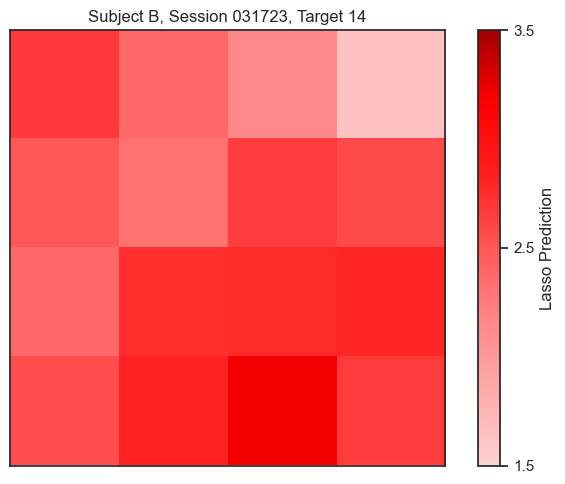

In [ ]:
def fig2D():
    def run_maps(fname):
        #data = utils.load_data(fname, region="OFC", query="trialerror == 0")
        data = nwbWrapper(fname, region="OFC")
        X = data.choice_spikes[:, 500:800, :].mean(axis=1)
        y = data.choice_df.graph_distance.values
        y[y >= 4] = 4
        y = 4 - y
        nodes = data.choice_df.node.values
        target = data.choice_df.target.values
        maps = {}
        model = Pipeline([("zscore", StandardScaler()), ("lasso", LassoCV())])
        model.fit(X, y)
        
        pred = model.predict(X)
        for j, targ in enumerate([1, 7, 8, 14]):
            map = np.zeros(16)
            for i in range(16):
                idx = (nodes == i) & (target == targ)
                map[i] = pred[idx].mean()
            maps[targ] = map
        return maps

    fnames = utils.get_filenames()
    maps = run_maps(fnames["bart"][2])

    colors = ["#ffd1d1", "#ffabab", "#ff8787", "#ff5757", "#ff1f1f", "#ff0000", "#a30000"]  # Define colors for the colormap
    custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

    fig, ax = plt.subplots(1, 1, figsize=(7, 5), tight_layout=True)
    map_14 = maps[14].reshape(4, 4)
    im = plt.imshow(map_14, cmap=custom_cmap, vmin=1.5, vmax=3.5)
    plt.title("Subject B, Session 031723, Target 14")
    plt.colorbar(im, ax=ax, ticks=[1.5, 2.5, 3.5], label="Lasso Prediction")
    ax.set_xticks([])
    ax.set_aspect("equal")
    ax.set_yticks([])
    return map_14

fig2D()

loading trial data:
loading trials:


100%|██████████| 893/893 [00:01<00:00, 831.61it/s]


loading choice data:


100%|██████████| 2417/2417 [00:01<00:00, 1796.18it/s]


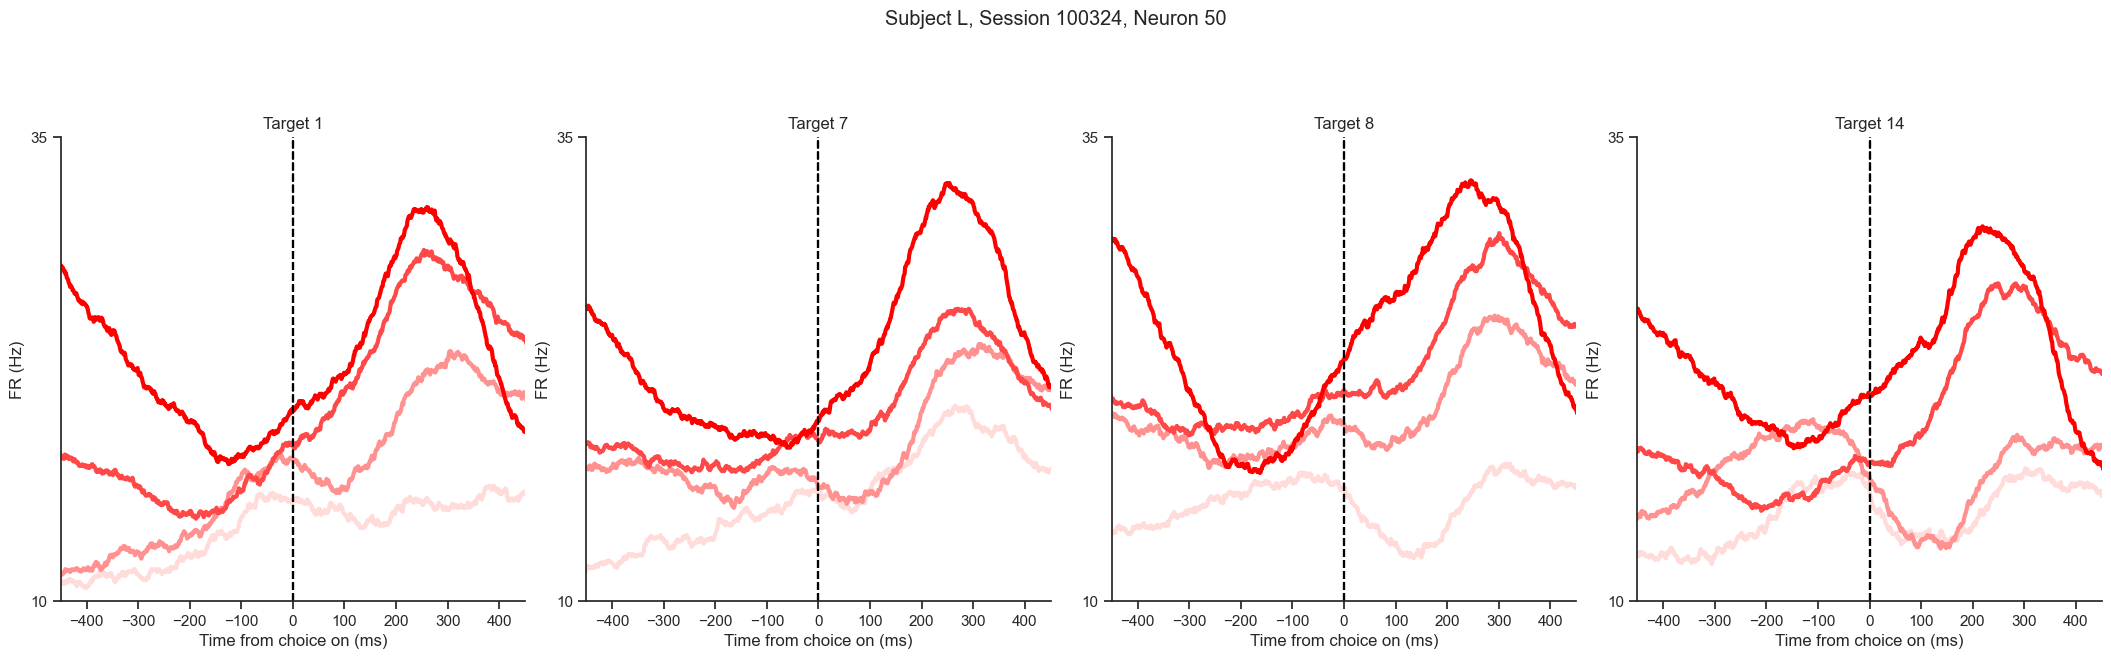

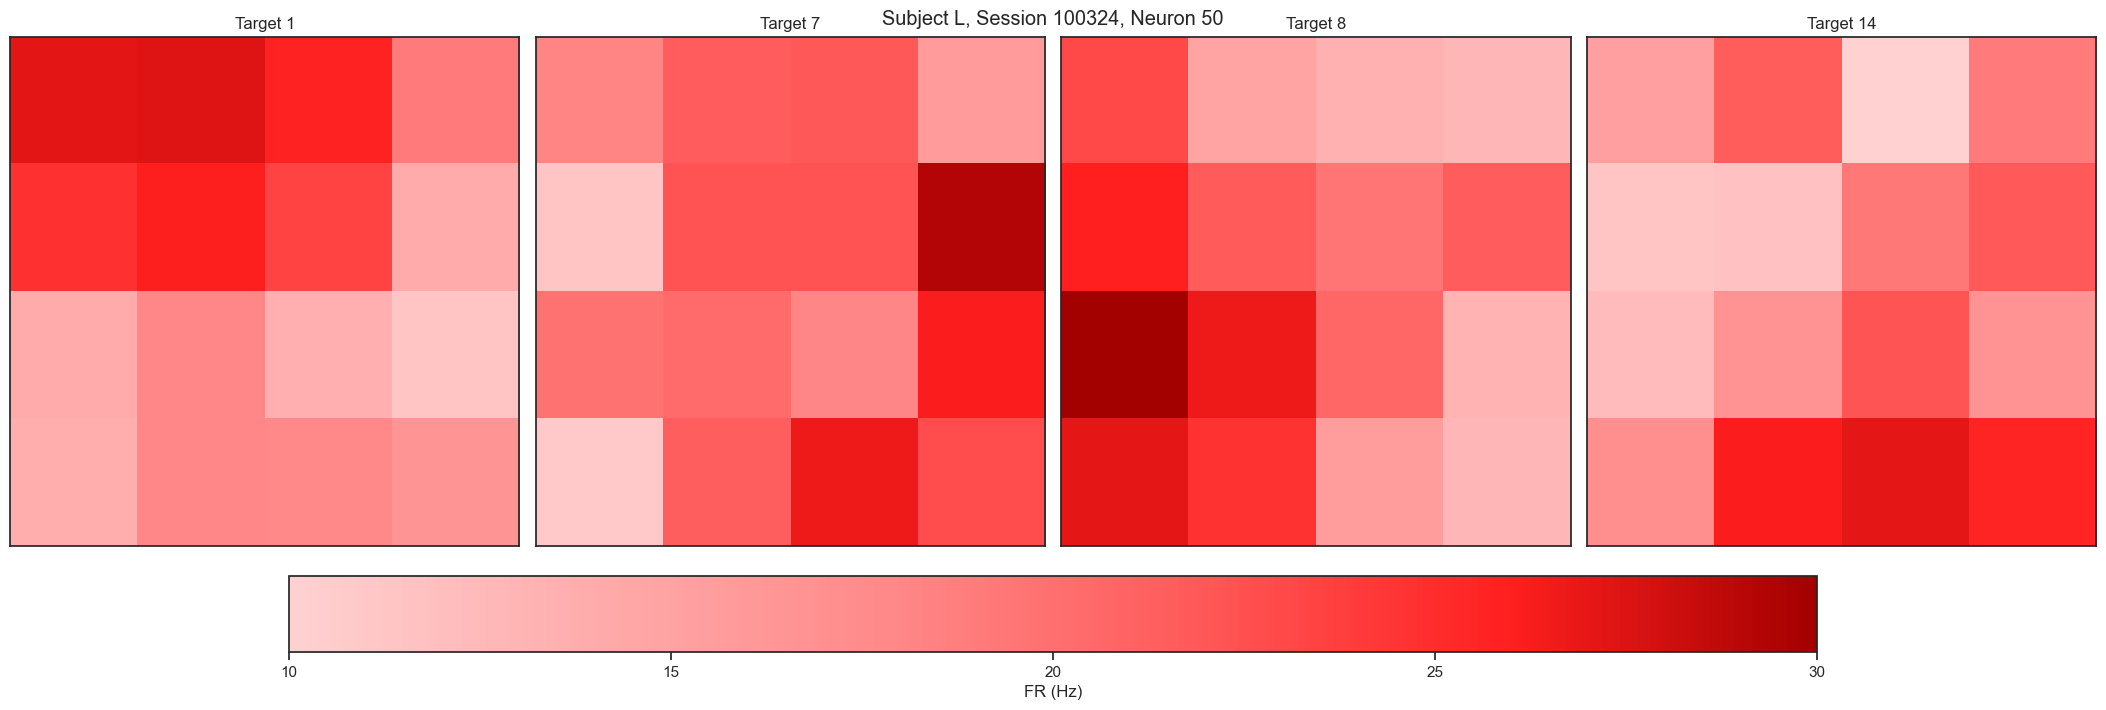

In [ ]:
def fig2e():
    psth_colors = plotting.interpolate_colors(color2="#ff0000", color1="#ffdbd9", num_colors=4)
    data = nwbWrapper(fnames["london"][4], region="OFC")
    neuron = 50

    # Plot firing rates over time
    fig, ax = plt.subplots(1, 4, figsize=(21, 7), constrained_layout=True)
    for j, target in enumerate([1, 7, 8, 14]):
        y = data.choice_df.graph_distance.values
        y[y >= 4] = 3
        y = 4 - y
        for i in range(4):
            t = np.arange(-500, 500)
            idx = (y == (i + 1)) & (data.choice_df.target == target)
            trace = data.choice_spikes[idx, :, neuron].mean(axis=0) * 1000
            trace = utils.movmean(trace, 100).flatten()
            ax[j].plot(t, trace, label=f"Distance {i}", color=psth_colors[i], lw=3)
            ax[j].set_xlim([-450, 450])
            ax[j].set_ylim([10, 35])
            ax[j].set_yticks([10, 35])
            ax[j].set_xlabel("Time from choice on (ms)")
            ax[j].set_ylabel("FR (Hz)")
            ax[j].axvline(0, color="black", linestyle="--", lw=1.5)
            ax[j].set_aspect(1.0 / ax[j].get_data_ratio(), adjustable='box')
            ax[j].set_title(f"Target {target}")
    sns.despine()
    fig.suptitle(f"Subject L, Session 100324, Neuron {neuron}")
    plt.show()

    # Plot firing rates as a heatmap
    colors = ["#ffd1d1", "#ffabab", "#ff8787", "#ff5757", "#ff1f1f", "#a30000"]  # Define colors for the colormap
    from matplotlib.colors import LinearSegmentedColormap
    custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

    fig, ax = plt.subplots(1, 4, figsize=(21, 7), constrained_layout=True)
    for j, target in enumerate([1, 7, 8, 14]):
        map = np.zeros(16)
        for i in range(16):
            idx = (data.choice_df.node == i) & (data.choice_df.target == target)
            map[i] = data.choice_spikes[idx, 600:900, neuron].mean() * 1000
        im = ax[j].imshow(map.reshape(4, 4), cmap=custom_cmap, vmin=10, vmax=30)
        ax[j].set_xticks([])
        ax[j].set_yticks([])
        ax[j].set_title(f"Target {target}")
        ax[j].set_aspect("equal")
    fig.colorbar(im, ax=ax, location="bottom", shrink=1, label="FR (Hz)", ticks=[10, 15, 20, 25, 30])
    fig.suptitle(f"Subject L, Session 100324, Neuron {neuron}")
    plt.show()

fig2e()

Processing bart:   0%|          | 0/8 [00:00<?, ?it/s]

loading trial data:
loading trials:


100%|██████████| 563/563 [00:00<00:00, 778.32it/s]


loading choice data:


Processing bart:  12%|█▎        | 1/8 [00:23<02:47, 23.94s/it]

...

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 666.10it/s]


loading choice data:


Processing london: 100%|██████████| 7/7 [02:39<00:00, 22.72s/it]

Subject B
|    |   index |   A |   B |   mean(A) |      mean(B) |      diff |       se |       T |     p-tukey |   hedges |
|---:|--------:|----:|----:|----------:|-------------:|----------:|---------:|--------:|------------:|---------:|
|  0 |       1 |   0 |   2 |  0.488483 | -0.000150243 | 0.488633  | 0.038575 | 12.6671 | 7.86078e-11 | 6.60563  |
|  1 |       2 |   1 |   2 |  0.430072 | -0.000150243 | 0.430223  | 0.038575 | 11.1529 | 8.16233e-10 | 6.40099  |
|  2 |       0 |   0 |   1 |  0.488483 |  0.430072    | 0.0584102 | 0.038575 |  1.5142 | 0.304705    | 0.584486 |
Subject L
|    |   index |   A |   B |   mean(A) |     mean(B) |     diff |        se |        T |     p-tukey |   hedges |
|---:|--------:|----:|----:|----------:|------------:|---------:|----------:|---------:|------------:|---------:|
|  0 |       1 |   0 |   2 |  0.666265 | 0.000290651 | 0.665974 | 0.0228032 | 29.2053  | 0           |  21.7165 |
|  1 |       2 |   1 |   2 |  0.589769 | 0.000290651 | 0.589478 | 0.

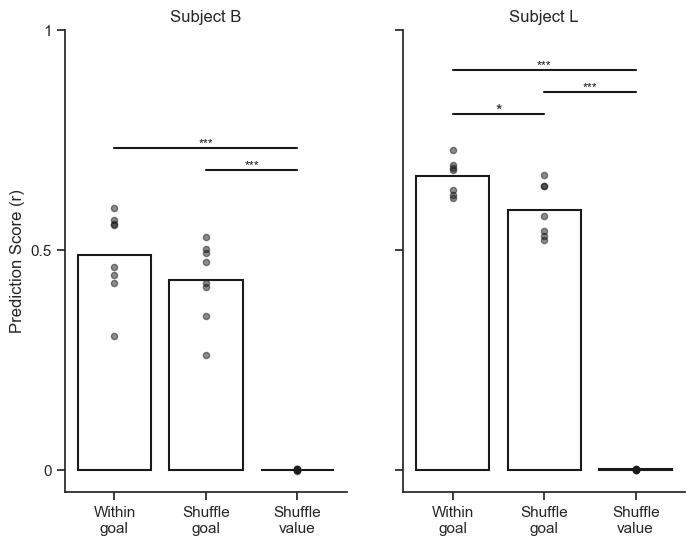

In [21]:
from sklearn.model_selection import train_test_split
def fig2F():
    
    def shuffle_target(fname):
        score_func = lambda y_true, y_pred: np.corrcoef(y_true, y_pred)[0, 1]
        n_shuffles = 100
        
        data = nwbWrapper(fname, region="OFC")
        y = data.choice_df.graph_distance.values
        y[y >= 3] = 3
        y = 4 - y
        X = data.choice_spikes[:, 500:800, :].mean(axis=1)
        targets = data.choice_df.target.values
        
        within_score = np.zeros(4)
        shuffle_target_score = np.zeros(4)
        shuffle_value_score = np.zeros(4)

        for i, train in enumerate([1, 7, 8, 14]):
            within_score_i = np.zeros(n_shuffles)
            shuffle_target_score_i = np.zeros(n_shuffles)
            shuffle_value_score_i = np.zeros(n_shuffles)
            
            for j in range(n_shuffles):
                model = Pipeline([("zscore", StandardScaler()), ("clf", LassoCV(cv=5, alphas=np.linspace(0.01, 0.02, 10)))])
                # Within score
                X_train, X_test, y_train, y_test = train_test_split(X[targets == train], y[targets ==train], test_size=0.25, shuffle=True)
                model.fit(X_train, y_train)
                predictions = model.predict(X_test)
                within_score_i[j] = score_func(y_test, predictions)
                
                # Shuffle target score
                model = Pipeline([("zscore", StandardScaler()), ("clf", LassoCV(cv=5, alphas=np.linspace(0.01, 0.02, 10)))])
                shuffle_targets = np.random.permutation(targets)
                model.fit(X[shuffle_targets == train], y[shuffle_targets == train])
                predictions = model.predict(X[shuffle_targets != train])
                shuffle_target_score_i[j] = score_func(y[shuffle_targets != train], predictions)

                # Shuffle value score
                model = Pipeline([("zscore", StandardScaler()), ("clf", LassoCV(cv=5, alphas=np.linspace(0.01, 0.02, 10)))])
                shuffle_y = np.random.permutation(y)
                model.fit(X[targets == train], shuffle_y[targets == train])
                predictions = model.predict(X[targets != train])
                shuffle_value_score_i[j] = score_func(shuffle_y[targets != train], predictions)
            
            within_score[i] = within_score_i.mean()
            shuffle_target_score[i] = shuffle_target_score_i.mean()
            shuffle_value_score[i] = shuffle_value_score_i.mean()
            
        return np.array([within_score.mean(), shuffle_target_score.mean(), shuffle_value_score.mean()])
    
    res_shuffle_target = utils.iterate_subjects(fnames, shuffle_target)
    
    fig, ax = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
    sns.set(style="ticks")
    for i, sbj in enumerate(res_shuffle_target.keys()):
        A = np.array(res_shuffle_target[sbj])
        ax[i].bar(np.arange(3), A.mean(axis=0), facecolor="white", edgecolor="k", linewidth=1.5)
        ax[i].scatter(np.arange(3).reshape(1, -1).repeat(len(A), axis=0).flatten(), A.flatten(), c="k", s=20, alpha=0.5)
        sns.despine()
        ax[i].set_title("Subject %s" % sbj[0].capitalize())
        ax[i].set_xticks([0, 1, 2], ["Within\ngoal", "Shuffle\ngoal", "Shuffle\nvalue"])

        n_sessions = len(A)
        id = np.repeat(np.arange(3).reshape(1, -1), n_sessions, axis=0).reshape(-1, 1)
        prediction_scores = A.reshape(-1, 1)
        hsd_res = pingouin.pairwise_tukey(data=pd.DataFrame({"id": id.flatten(), "prediction_scores": prediction_scores.flatten()}),
                                dv="prediction_scores", between="id").sort_values("p-tukey").reset_index()
        print("Subject %s" % sbj[0].capitalize())
        print(hsd_res.to_markdown())
        
        for j, row in hsd_res.iterrows():
            bias = j*0.05
            y =  A.mean(axis=0).max() + 0.25 - bias
            y2 = y - 0.0075
            if row["p-tukey"] < 1e-4:
                ax[i].text((row["A"] + row["B"])/2, y, "***", ha="center", va="center", fontsize=9)
                ax[i].plot([row["A"], row["B"]], [y2, y2], c="k", linewidth=1.5)
            elif row["p-tukey"] < 0.01:
                ax[i].text((row["A"] + row["B"])/2, y, "*", ha="center", va="center")
                ax[i].plot([row["A"], row["B"]], [y2, y2], c="k", linewidth=1.5)
                
    ax[0].set_ylim([-0.05, 1])
    ax[0].set_yticks([0, 0.5, 1], labels=["0", "0.5", "1"])
    ax[0].set_ylabel("Prediction Score (r)")

fig2F()

Processing bart:   0%|          | 0/8 [00:00<?, ?it/s]

loading trial data:
loading trials:


100%|██████████| 563/563 [00:00<00:00, 766.11it/s]


loading choice data:


Processing bart:  12%|█▎        | 1/8 [00:04<00:33,  4.81s/it]

...

Processing london:  86%|████████▌ | 6/7 [00:43<00:07,  7.16s/it]

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 641.59it/s]


loading choice data:


Processing london: 100%|██████████| 7/7 [00:52<00:00,  7.44s/it]


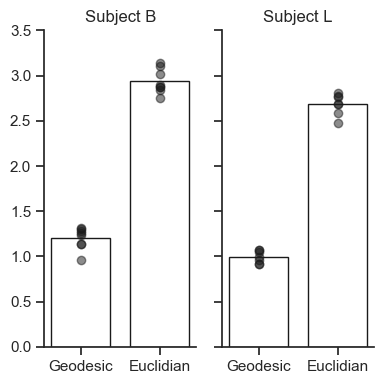

In [32]:
def fig2G():
    fnames = utils.get_filenames()

    def run_geo_vs_euc(fname):
        data = nwbWrapper(fname, region="OFC")
        X = data.choice_spikes[:, 500:800, :].mean(axis=1)
        y_geo = data.choice_df.graph_distance.values
        y_euc = data.choice_df.apply(lambda row: graph.distance(row.node, row.target, type="space"), axis=1).values
        
        train = np.where(y_geo == y_euc)[0]
        test = np.where(y_geo != y_euc)[0]

        #y_geo[y_geo >= 4] = 4
        #y_geo = 4 - y_geo
        
        #y_euc[y_euc >= 4] = 4
        #y_euc = 4 - y_euc

        model = Pipeline([("zscore", StandardScaler()), ("lasso", LassoCV())])
        model.fit(X[train], y_geo[train])
        return mean_squared_error(y_geo[test], model.predict(X[test])), mean_squared_error(y_euc[test], model.predict(X[test]))

    geo_vs_euc = utils.iterate_subjects(fnames, run_geo_vs_euc)
    _, ax = plt.subplots(1, 2, figsize=(4, 4), tight_layout=True, sharey=True)
    for j, key in enumerate(geo_vs_euc):
        geo_vs_euc[key]= np.sqrt(np.array(geo_vs_euc[key]))
        geo = geo_vs_euc[key][:, 0]
        ax[j].scatter(np.zeros_like(geo), geo, c="k", alpha=0.5)
        ax[j].bar(0, geo.mean(), facecolor="none", alpha=1, width=0.75, edgecolor="k")
        euc = geo_vs_euc[key][:, 1]
        ax[j].scatter(np.ones_like(euc), euc, c="k", alpha=0.5)
        ax[j].bar(1, euc.mean(), facecolor="none", alpha=1, width=0.75, edgecolor="k")
        ax[j].set_ylim([0, 3.5])
        ax[j].set_xticks([0, 1])
        ax[j].set_xticklabels(["Geodesic", "Euclidian"])
        ax[j].set_title("Subject " + key[0].capitalize())
        sns.despine()
    
    return geo_vs_euc
geo_vs_euc = fig2G()